In [1]:
import numpy as np
import pandas as pd


class FreetownHydrologyPipeline:

  def __init__(
      self, curve_number: float = 75.0, antecedent_window: int = 5
  ):
    """Initializes the hydrological feature engineering pipeline.

    Parameters:
    - curve_number (float): SCS Curve Number representing soil and land cover
    characteristics (default 75 for urbanizing slopes).
    - antecedent_window (int): Number of prior days to calculate Antecedent
    Moisture Condition (AMC).
    """
    self.cn = curve_number
    self.amc_window = antecedent_window
    # Calculate potential maximum retention S (in millimeters) from Curve Number
    self.s_initial = (25400 / self.cn) - 254

  def compute_scs_runoff(self, df: pd.DataFrame, rainfall_col: str) -> pd.DataFrame:
    """Computes direct surface runoff depth (Q) from daily rainfall (P)

    using the SCS Curve Number equation: Q = (P - 0.2S)^2 / (P + 0.8S)
    """
    df = df.copy()
    p = df[rainfall_col].values

    # Initial abstraction threshold (0.2 * S). Runoff only occurs if P > 0.2S
    initial_abstraction = 0.2 * self.s_initial

    # Vectorized SCS calculation
    q = np.where(
        p > initial_abstraction,
        ((p - initial_abstraction) ** 2) / (p + (0.8 * self.s_initial)),
        0.0,
    )

    df["effective_runoff_mm"] = q
    return df

  def compute_antecedent_precipitation(
      self, df: pd.DataFrame, rainfall_col: str
  ) -> pd.DataFrame:
    """Computes rolling antecedent precipitation indexes to account

    for soil saturation levels prior to an event.
    """
    df = df.copy()
    # 5-day rolling sum of rainfall
    df[f"antecedent_rain_{self.amc_window}d"] = (
        df[rainfall_col].rolling(window=self.amc_window, min_periods=1).sum()
    )
    return df

  def generate_lagged_features(
      self, df: pd.DataFrame, cols: list, lags: list
  ) -> pd.DataFrame:
    """Generates temporal lags for time-series memory (e.g., t-1, t-2, t-3 days)"""
    df = df.copy()
    for col in cols:
      for lag in lags:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

  def fit_transform(
      self, df: pd.DataFrame, rainfall_col: str = "rainfall_mm"
  ) -> pd.DataFrame:
    """Executes the full feature engineering pipeline sequentially."""
    print("Executing Phase 2: Hydrological Feature Engineering...")

    # Step 1: Antecedent moisture calculation
    df = self.compute_antecedent_precipitation(df, rainfall_col)

    # Step 2: SCS Curve Number Runoff Calculation
    df = self.compute_scs_runoff(df, rainfall_col)

    # Step 3: Create temporal lags for machine learning input (past 1 to 3 days)
    feature_cols = [rainfall_col, "effective_runoff_mm", f"antecedent_rain_{self.amc_window}d"]
    df = self.generate_lagged_features(df, cols=feature_cols, lags=[1, 2, 3])

    # Drop rows containing NaNs created by lagging/rolling windows
    df = df.dropna().reset_index(drop=True)

    print(f"Feature matrix generated successfully. Final shape: {df.shape}")
    return df


# --- Example Usage Validation ---
if __name__ == "__main__":
  # Mock dataset representing time-series weather station data for Freetown
  np.random.seed(42)
  dates = pd.date_range(start="2025-06-01", end="2025-10-31", freq="D")
  mock_data = pd.DataFrame({
      "date": dates,
      "rainfall_mm": np.clip(
          np.random.exponential(scale=15, size=len(dates))
          + np.sin(np.linspace(0, 10, len(dates))) * 10,
          0,
          150,
      ),
  })

  # Initialize and execute pipeline
  pipeline = FreetownHydrologyPipeline(curve_number=80.0) # Higher CN for urban surfaces
  processed_df = pipeline.fit_transform(mock_data, rainfall_col="rainfall_mm")
  print(processed_df.head(3))

Executing Phase 2: Hydrological Feature Engineering...
Feature matrix generated successfully. Final shape: (150, 13)
        date  rainfall_mm  antecedent_rain_5d  effective_runoff_mm  \
0 2025-06-04    15.655034           89.566478               0.1314   
1 2025-06-05     5.145683           94.712161               0.0000   
2 2025-06-06     5.774415           93.447555               0.0000   

   rainfall_mm_lag_1  rainfall_mm_lag_2  rainfall_mm_lag_3  \
0          21.063181          45.809242           7.039021   
1          15.655034          21.063181          45.809242   
2           5.145683          15.655034          21.063181   

   effective_runoff_mm_lag_1  effective_runoff_mm_lag_2  \
0                   0.973277                  11.346967   
1                   0.131400                   0.973277   
2                   0.000000                   0.131400   

   effective_runoff_mm_lag_3  antecedent_rain_5d_lag_1  \
0                   0.000000                 73.911445   


In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import TimeSeriesSplit


class FreetownFloodClassifier:

  def __init__(self):
    # Using Random Forest as an interpretable, high-performance baseline
    self.binary_model = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    )
    self.severity_model = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    )

  def generate_synthetic_targets(self, df: pd.DataFrame) -> pd.DataFrame:
    """Simulates realistic operational flood labels using physical thresholds

    (runoff and saturated soil memory) for demonstration purposes.
    """
    df = df.copy()

    # Rule-based thresholding reflecting Freetown's flash-flood susceptibility
    # High runoff combined with saturated antecedent soil creates high risk
    flood_score = (df["effective_runoff_mm"] * 1.5) + (
        df["antecedent_rain_5d"] * 0.05
    )

    # Target A: Binary Probability (0 = Safe, 1 = Flood Alert)
    threshold_binary = np.percentile(flood_score, 85)  # Top 15% event frequency
    df["target_binary"] = (flood_score >= threshold_binary).astype(int)

    # Target B: Multi-Class Severity (0: None, 1: Low, 2: Moderate, 3: High)
    conditions = [
        (flood_score < np.percentile(flood_score, 70)),
        (
            (flood_score >= np.percentile(flood_score, 70))
            & (flood_score < np.percentile(flood_score, 90))
        ),
        (
            (flood_score >= np.percentile(flood_score, 90))
            & (flood_score < np.percentile(flood_score, 97))
        ),
        (flood_score >= np.percentile(flood_score, 97)),
    ]
    choices = [0, 1, 2, 3]
    df["target_severity"] = np.select(conditions, choices, default=0)

    return df

  def train_and_evaluate(self, df: pd.DataFrame):
    """Trains models using Time-Series Cross-Validation to prevent data leakage."""
    print("\nExecuting Phase 3: Model Training & Evaluation...")

    # Define feature set (dropping dates and targets)
    feature_cols = [
        col for col in df.columns if col not in ["date", "target_binary", "target_severity"]
    ]
    X = df[feature_cols]
    y_bin = df["target_binary"]
    y_sev = df["target_severity"]

    # Time-Series Split (crucial for time-dependent weather data)
    tscv = TimeSeriesSplit(n_splits=3)

    print("\n--- Training Target A: Binary Flood Probability ---")
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y_bin.iloc[train_index], y_bin.iloc[test_index]

      self.binary_model.fit(X_train, y_train)
      preds = self.binary_model.predict(X_test)
      score = f1_score(y_test, preds, zero_division=0)
      print(f"Fold {fold+1} Binary F1-Score: {score:.3f}")

    print("\n--- Training Target B: Multi-Class Severity ---")
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y_sev.iloc[train_index], y_sev.iloc[test_index]

      self.severity_model.fit(X_train, y_train)
      preds = self.severity_model.predict(X_test)
      score = f1_score(y_test, preds, average="macro", zero_division=0)
      print(f"Fold {fold+1} Severity Macro-F1: {score:.3f}")

    return self.binary_model, self.severity_model


# --- Integration Test ---
if __name__ == "__main__":
  # Assuming processed_df from previous step is available
  # For execution continuity, we simulate running it on the processed data frame structure
  np.random.seed(42)
  # Mocking a processed dataframe matching your shape (150, 13)
  mock_processed = pd.DataFrame(
      np.random.rand(150, 13),
      columns=[
          "date_placeholder",
          "rainfall_mm",
          "antecedent_rain_5d",
          "effective_runoff_mm",
          "rainfall_mm_lag_1",
          "rainfall_mm_lag_2",
          "rainfall_mm_lag_3",
          "effective_runoff_mm_lag_1",
          "effective_runoff_mm_lag_2",
          "effective_runoff_mm_lag_3",
          "antecedent_rain_5d_lag_1",
          "antecedent_rain_5d_lag_2",
          "antecedent_rain_5d_lag_3",
      ],
  )
  mock_processed["date"] = pd.date_range(start="2025-06-04", periods=150, freq="D")

  classifier_pipeline = FreetownFloodClassifier()
  labeled_df = classifier_pipeline.generate_synthetic_targets(mock_processed)
  bin_model, sev_model = classifier_pipeline.train_and_evaluate(labeled_df)


Executing Phase 3: Model Training & Evaluation...

--- Training Target A: Binary Flood Probability ---
Fold 1 Binary F1-Score: 0.000
Fold 2 Binary F1-Score: 0.600
Fold 3 Binary F1-Score: 0.857

--- Training Target B: Multi-Class Severity ---
Fold 1 Severity Macro-F1: 0.535
Fold 2 Severity Macro-F1: 0.456
Fold 3 Severity Macro-F1: 0.464


In [5]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point


class FreetownSpatialHydrologyPipeline:

  def __init__(self, catchment_shapefile_path: str):
    """Initializes the spatial pipeline with QGIS shapefiles for Freetown catchments

    (e.g., Mountain Cut, Congo Town, Lumley drainage zones).
    """
    print(f"Loading spatial boundaries from: {catchment_shapefile_path}")
    self.catchments = gpd.read_file(catchment_shapefile_path)

  def extract_topographic_features(
      self, weather_stations_df: pd.DataFrame, lat_col: str, lon_col: str
  ) -> pd.DataFrame:
    """Performs spatial joins between weather stations/rain gauges

    and Freetown catchment zones to assign topographic variables
    (e.g., mean slope, elevation, basin area).
    """
    # Convert dataframe to a GeoDataFrame using station coordinates
    geometry = [
        Point(xy) for xy in zip(weather_stations_df[lon_col], weather_stations_df[lat_col])
    ]
    stations_gdf = gpd.GeoDataFrame(
        weather_stations_df, geometry=geometry, crs="EPSG:4326"
    )

    # Ensure coordinate reference systems match
    if stations_gdf.crs != self.catchments.crs:
      stations_gdf = stations_gdf.to_crs(self.catchments.crs)

    # Spatial join to find which catchment each station/grid point belongs to
    spatial_joined = gpd.sjoin(
        stations_gdf, self.catchments, how="inner", predicate="within"
    )

    # Convert back to standard pandas dataframe, retaining spatial attributes
    df_features = pd.DataFrame(spatial_joined.drop(columns="geometry"))
    return df_features

In [7]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask


class FreetownDEMProcessor:

  def __init__(self, dem_path: str, catchments_shapefile_path: str):
    """Initializes the DEM processor with a local raster file (SRTM/DEM)

    and Freetown catchment boundaries (QGIS shapefiles).
    """
    self.dem_path = dem_path
    self.catchments = gpd.read_file(catchments_shapefile_path)

  def extract_topographic_stats(self) -> gpd.GeoDataFrame:
    """Extracts mean elevation and slope characteristics for each

    Freetown catchment zone from the DEM raster.
    """
    print("Processing Digital Elevation Model (DEM) for Freetown catchments...")

    elevation_means = []
    slope_means = []

    with rasterio.open(self.dem_path) as src:
      # Ensure shapefiles match raster CRS
      if self.catchments.crs != src.crs:
        catchments_proj = self.catchments.to_crs(src.crs)
      else:
        catchments_proj = self.catchments

      for geom in catchments_proj.geometry:
        try:
          # Mask raster using catchment polygon geometry
          out_image, out_transform = mask(src, [geom], crop=True)
          data = out_image[0]  # First band (elevation)

          # Ignore NoData values (e.g., negative elevations or missing pixels)
          valid_data = data[data > 0]

          if valid_data.size > 0:
            mean_elev = np.mean(valid_data)
            # Approximate slope calculation from elevation gradients (dx, dy)
            dy, dx = np.gradient(data)
            slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)
            mean_slope = np.mean(slope[data > 0])
          else:
            mean_elev, mean_slope = 0.0, 0.0

          elevation_means.append(mean_elev)
          slope_means.append(mean_slope)

        except Exception as e:
          elevation_means.append(0.0)
          slope_means.append(0.0)

    # Attach features back to the GeoDataFrame
    self.catchments["mean_elevation_m"] = elevation_means
    self.catchments["mean_slope_deg"] = slope_means

    print("DEM topographic feature extraction complete.")
    return self.catchments


# --- Example Execution ---
if __name__ == "__main__":
  # Path placeholders for local QGIS files
  DEM_FILE = "freetown_dem.tif"
  CATCHMENTS_SHP = "freetown_catchments.shp"

  # dem_processor = FreetownDEMProcessor(DEM_FILE, CATCHMENTS_SHP)
  # spatial_features_df = dem_processor.extract_topographic_stats()

In [7]:
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Polygon


class FreetownCleanSpatialPipeline:

  def __init__(self):
    print(
        "Initializing Clean-Slate Spatial Pipeline for Freetown Catchments..."
    )

  def generate_catchment_baselines(self) -> gpd.GeoDataFrame:
    """Programmatically defines key Freetown flood-prone catchments

    with realistic baseline topography (elevation and slope) from scratch.
    """
    # Approximate bounding coordinates for key Freetown drainage zones
    catchment_data = {
        "catchment_id": [
            "Mountain_Cut",
            "Congo_Town",
            "Lumley_Basin",
            "Kroo_Bay",
        ],
        # Simulated topographic baselines reflecting steep mountain gradients to coast
        "mean_elevation_m": [280.5, 145.2, 45.8, 12.0],
        "mean_slope_deg": [
            24.5,
            16.2,
            8.1,
            3.0,
        ],  # Steeper upper slopes = faster flash floods
        "geometry": [
            Polygon([
                (-13.23, 8.48),
                (-13.21, 8.48),
                (-13.21, 8.46),
                (-13.23, 8.46),
            ]),
            Polygon([
                (-13.25, 8.47),
                (-13.23, 8.47),
                (-13.23, 8.45),
                (-13.25, 8.45),
            ]),
            Polygon([
                (-13.27, 8.46),
                (-13.25, 8.46),
                (-13.25, 8.44),
                (-13.27, 8.44),
            ]),
            Polygon([
                (-13.24, 8.49),
                (-13.22, 8.49),
                (-13.22, 8.47),
                (-13.24, 8.47),
            ]),
        ],
    }

    gdf = gpd.GeoDataFrame(catchment_data, crs="EPSG:4326")
    print(f"Created {len(gdf)} clean Freetown catchment zones.")
    return gdf

  def merge_spatial_with_hydrology(
      self, hydrology_df: pd.DataFrame, catchments_gdf: gpd.GeoDataFrame
  ) -> pd.DataFrame:
    """Merges static spatial/topographic features with time-series rainfall-runoff data."""
    # For a city-wide model, we replicate spatial characteristics across the timeline or join by zone
    master_dfs = []
    for _, catchment in catchments_gdf.iterrows():
      temp_df = hydrology_df.copy()
      temp_df["catchment_id"] = catchment["catchment_id"]
      temp_df["mean_elevation_m"] = catchment["mean_elevation_m"]
      temp_df["mean_slope_deg"] = catchment["mean_slope_deg"]
      master_dfs.append(temp_df)

    master_feature_matrix = pd.concat(master_dfs, ignore_index=True)
    print(
        "Master feature matrix generated successfully. Shape:"
        f" {master_feature_matrix.shape}"
    )
    return master_feature_matrix


# --- Execution Test ---
if __name__ == "__main__":
  # 1. Generate clean spatial baselines
  spatial_pipeline = FreetownCleanSpatialPipeline()
  catchments = spatial_pipeline.generate_catchment_baselines()

  # 2. Mocking our earlier processed time-series weather dataframe
  np.random.seed(42)
  mock_hydro_df = pd.DataFrame({
      "date": pd.date_range(start="2025-06-01", periods=10, freq="D"),
      "rainfall_mm": np.random.uniform(5, 80, 10),
      "effective_runoff_mm": np.random.uniform(0, 40, 10),
      "antecedent_rain_5d": np.random.uniform(20, 150, 10),
  })

  # 3. Create unified master dataset
  master_data = spatial_pipeline.merge_spatial_with_hydrology(
      mock_hydro_df, catchments
  )
  print(master_data.head(3))

Initializing Clean-Slate Spatial Pipeline for Freetown Catchments...
Created 4 clean Freetown catchment zones.
Master feature matrix generated successfully. Shape: (40, 7)
        date  rainfall_mm  effective_runoff_mm  antecedent_rain_5d  \
0 2025-06-01    33.090509             0.823380           99.540876   
1 2025-06-02    76.303573            38.796394           38.134202   
2 2025-06-03    59.899546            33.297706           57.978804   

   catchment_id  mean_elevation_m  mean_slope_deg  
0  Mountain_Cut             280.5            24.5  
1  Mountain_Cut             280.5            24.5  
2  Mountain_Cut             280.5            24.5  


In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder


class EnhancedFreetownFloodClassifier:

  def __init__(self):
    self.binary_model = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    )
    self.severity_model = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    )

  def generate_targets(self, df: pd.DataFrame) -> pd.DataFrame:
    """Generates synthetic targets driven by physical runoff and slope risk."""
    df = df.copy()

    # Flood score combines runoff, antecedent moisture, and slope steepness
    flood_score = (
        (df["effective_runoff_mm"] * 1.2)
        + (df["antecedent_rain_5d"] * 0.04)
        + (
            df["mean_slope_deg"] * 0.5
        )  # Steeper catchments increase flash flood risk
    )

    # Target A: Binary Probability (0 = Safe, 1 = Flood Alert)
    threshold_binary = np.percentile(flood_score, 80)
    df["target_binary"] = (flood_score >= threshold_binary).astype(int)

    # Target B: Multi-Class Severity (0: None, 1: Low, 2: Moderate, 3: High)
    conditions = [
        (flood_score < np.percentile(flood_score, 65)),
        (
            (flood_score >= np.percentile(flood_score, 65))
            & (flood_score < np.percentile(flood_score, 85))
        ),
        (
            (flood_score >= np.percentile(flood_score, 85))
            & (flood_score < np.percentile(flood_score, 95))
        ),
        (flood_score >= np.percentile(flood_score, 95)),
    ]
    df["target_severity"] = np.select(conditions, [0, 1, 2, 3], default=0)

    return df

  def train_and_evaluate(self, df: pd.DataFrame):
    print("\nExecuting Phase 3: Enhanced Model Training & Evaluation...")

    # One-hot encode the categorical catchment_id
    df_encoded = pd.get_dummies(df, columns=["catchment_id"], drop_first=True)

    # Define feature set (dropping dates and targets)
    feature_cols = [
        col
        for col in df_encoded.columns
        if col not in ["date", "target_binary", "target_severity"]
    ]
    X = df_encoded[feature_cols]
    y_bin = df_encoded["target_binary"]
    y_sev = df_encoded["target_severity"]

    # Time-Series Split
    tscv = TimeSeriesSplit(n_splits=3)

    print("\n--- Training Target A: Binary Flood Probability ---")
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y_bin.iloc[train_index], y_bin.iloc[test_index]

      self.binary_model.fit(X_train, y_train)
      preds = self.binary_model.predict(X_test)
      score = f1_score(y_test, preds, zero_division=0)
      print(f"Fold {fold+1} Binary F1-Score: {score:.3f}")

    print("\n--- Training Target B: Multi-Class Severity ---")
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y_sev.iloc[train_index], y_sev.iloc[test_index]

      self.severity_model.fit(X_train, y_train)
      preds = self.severity_model.predict(X_test)
      score = f1_score(y_test, preds, average="macro", zero_division=0)
      print(f"Fold {fold+1} Severity Macro-F1: {score:.3f}")

    return self.binary_model, self.severity_model


# --- Execution Test ---
if __name__ == "__main__":
  # Assuming master_data is your dataframe from the previous step:
  # trainer = EnhancedFreetownFloodClassifier()
  # labeled_master_df = trainer.generate_targets(master_data)
  # bin_model, sev_model = trainer.train_and_evaluate(labeled_master_df)
  pass

In [3]:
import sys

!{sys.executable} -m pip install fastapi uvicorn pydantic

In [5]:
import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

# Initialize FastAPI app
app = FastAPI(
    title="Freetown Flood Early Warning API",
    version="1.0",
    description=(
        "Production ML service predicting flood probability and severity for"
        " Freetown catchments."
    ),
)


# Define request payload structure
class FloodPredictionRequest(BaseModel):
  catchment_id: str
  rainfall_mm: float
  effective_runoff_mm: float
  antecedent_rain_5d: float
  mean_elevation_m: float
  mean_slope_deg: float


@app.post("/predict")
def predict_flood_risk(data: FloodPredictionRequest):
  try:
    # Convert incoming request to DataFrame
    input_data = pd.DataFrame([data.dict()])

    # One-hot encode catchment_id to match training schema
    # (In a true production app, load a saved ColumnTransformer/Pipeline)
    catchments = ["Mountain_Cut", "Congo_Town", "Lumley_Basin", "Kroo_Bay"]
    for c in catchments:
      input_data[f"catchment_id_{c}"] = (
          1 if input_data["catchment_id"].iloc[0] == c else 0
      )

    input_data = input_data.drop(columns=["catchment_id"])

    # Placeholder: In production, load pre-trained models via joblib.load('model.pkl')
    # For demonstration, we simulate model inference logic based on thresholds
    risk_score = (
        input_data["effective_runoff_mm"].iloc[0] * 1.2
        + input_data["antecedent_rain_5d"].iloc[0] * 0.04
        + input_data["mean_slope_deg"].iloc[0] * 0.5
    )

    binary_pred = 1 if risk_score > 60 else 0
    severity_pred = (
        3 if risk_score > 90 else (2 if risk_score > 75 else (1 if risk_score > 50 else 0))
    )

    return {
        "status": "success",
        "flood_probability_alert": int(binary_pred),
        "flood_severity_level": int(severity_pred),
        "calculated_risk_score": round(float(risk_score), 2),
    }

  except Exception as e:
    raise HTTPException(status_code=500, detail=str(e))

In [25]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


class OptimizedFreetownModelTrainer:

  def __init__(self):
    print(
        "Initializing Optimized & Regularized Model Training Pipeline..."
    )

  def optimize_and_train(self, X: pd.DataFrame, y: pd.Series, target_name: str):
    """Performs Time-Series Cross-Validation hyperparameter tuning with regularization."""
    print(f"\n--- Optimizing Hyperparameters for: {target_name} ---")

    # Base model with class weighting for imbalance
    base_model = RandomForestClassifier(
        random_state=42, class_weight="balanced", n_jobs=-1
    )

    # Hyperparameter search space with built-in regularization bounds
    param_distributions = {
        "n_estimators": [50, 100, 200],
        "max_depth": [4, 6, 8, 10, None],  # Regularization: limits tree depth
        "min_samples_split": [
            5,
            10,
            20,
        ],  # Regularization: requires samples to split
        "min_samples_leaf": [
            2,
            5,
            10,
        ],  # Regularization: ensures robust leaf nodes
        "max_features": ["sqrt", "log2", 0.8],  # Feature subsampling
    }

    # Time-series split to prevent data leakage
    tscv = TimeSeriesSplit(n_splits=3)

    # Randomized search setup
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=10,
        scoring="f1_macro" if "severity" in target_name else "f1",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
    )

    search.fit(X, y)

    print(f"Best Parameters for {target_name}:")
    for param, value in search.best_params_.items():
      print(f"  - {param}: {value}")

    print(f"Best Cross-Validation Score: {search.best_score_:.3f}")
    return search.best_estimator_


# --- Integration Test ---
if __name__ == "__main__":
  # Mocking a processed feature matrix to test the tuner
  np.random.seed(42)
  X_mock = pd.DataFrame(
      np.random.rand(100, 8),
      columns=[
          "rainfall_mm",
          "effective_runoff_mm",
          "antecedent_rain_5d",
          "mean_elevation_m",
          "mean_slope_deg",
          "rainfall_mm_lag_1",
          "effective_runoff_mm_lag_1",
          "catchment_id_Mountain_Cut",
      ],
  )
  y_mock_binary = pd.Series(np.random.choice([0, 1], size=100, p=[0.8, 0.2]))

  trainer = OptimizedFreetownModelTrainer()
  best_binary_model = trainer.optimize_and_train(
      X_mock, y_mock_binary, "Binary Flood Probability"
  )

Initializing Optimized & Regularized Model Training Pipeline...

--- Optimizing Hyperparameters for: Binary Flood Probability ---
Best Parameters for Binary Flood Probability:
  - n_estimators: 200
  - min_samples_split: 10
  - min_samples_leaf: 10
  - max_features: 0.8
  - max_depth: 4
Best Cross-Validation Score: 0.242


In [31]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


class FreetownFloodPipelineMaster:

  def __init__(self):
    print(
        "Initializing Freetown Flood Early Warning Master Pipeline (Phases 2"
        " & 3)..."
    )

  def step_1_generate_raw_data(self) -> pd.DataFrame:
    """Simulates realistic historical weather station data for Freetown."""
    np.random.seed(42)
    dates = pd.date_range(start="2025-06-01", periods=120, freq="D")

    # Simulate monsoon rainfall spikes typical of Freetown
    rainfall = np.clip(
        np.random.exponential(scale=18, size=len(dates))
        + np.sin(np.linspace(0, 15, len(dates))) * 15,
        0,
        180,
    )

    df = pd.DataFrame({"date": dates, "rainfall_mm": rainfall})
    return df

  def step_2_engineering_features(self, df: pd.DataFrame) -> pd.DataFrame:
    """Applies SCS Curve Number runoff physics, antecedent moisture, and spatial data."""
    df = df.copy()

    # 1. Antecedent Precipitation (5-day rolling sum)
    df["antecedent_rain_5d"] = (
        df["rainfall_mm"].rolling(window=5, min_periods=1).sum()
    )

    # 2. SCS Curve Number Runoff Calculation (Curve Number = 80 for urbanizing slopes)
    cn = 80.0
    s_initial = (25400 / cn) - 254
    initial_abstraction = 0.2 * s_initial
    p = df["rainfall_mm"].values

    df["effective_runoff_mm"] = np.where(
        p > initial_abstraction,
        ((p - initial_abstraction) ** 2) / (p + (0.8 * s_initial)),
        0.0,
    )

    # 3. Temporal Lags
    df["rainfall_mm_lag_1"] = df["rainfall_mm"].shift(1).fillna(0)
    df["effective_runoff_mm_lag_1"] = (
        df["effective_runoff_mm"].shift(1).fillna(0)
    )

    # 4. Integrate Spatial Baselines (Freetown Micro-Catchments)
    catchments = [
        {
            "catchment_id": "Mountain_Cut",
            "mean_elevation_m": 280.5,
            "mean_slope_deg": 24.5,
        },
        {
            "catchment_id": "Congo_Town",
            "mean_elevation_m": 145.2,
            "mean_slope_deg": 16.2,
        },
        {
            "catchment_id": "Lumley_Basin",
            "mean_elevation_m": 45.8,
            "mean_slope_deg": 8.1,
        },
        {
            "catchment_id": "Kroo_Bay",
            "mean_elevation_m": 12.0,
            "mean_slope_deg": 3.0,
        },
    ]

    master_list = []
    for c in catchments:
      temp_df = df.copy()
      temp_df["catchment_id"] = c["catchment_id"]
      temp_df["mean_elevation_m"] = c["mean_elevation_m"]
      temp_df["mean_slope_deg"] = c["mean_slope_deg"]
      master_list.append(temp_df)

    master_df = pd.concat(master_list, ignore_index=True)
    return master_df

  def step_3_generate_targets(self, df: pd.DataFrame) -> pd.DataFrame:
    """Generates physical binary flood probability targets."""
    df = df.copy()

    # Physical risk score: Runoff + antecedent moisture + steep slopes = flood risk
    risk_score = (
        (df["effective_runoff_mm"] * 1.5)
        + (df["antecedent_rain_5d"] * 0.05)
        + (df["mean_slope_deg"] * 0.4)
        + np.random.normal(0, 2, len(df))  # Add slight real-world noise
    )

    # Top 20% risk threshold constitutes a flood alert event
    threshold = np.percentile(risk_score, 80)
    df["target_binary"] = (risk_score >= threshold).astype(int)

    return df

  def step_4_train_optimized_model(self, df: pd.DataFrame):
    """Trains an optimized, regularized Random Forest using Time-Series CV and saves artifacts."""
    print("\nExecuting Phase 3: Optimized Model Training...")

    # One-hot encode catchment IDs
    df_encoded = pd.get_dummies(df, columns=["catchment_id"], drop_first=True)

    feature_cols = [
        col for col in df_encoded.columns if col not in ["date", "target_binary"]
    ]
    X = df_encoded[feature_cols]
    y = df_encoded["target_binary"]

    base_model = RandomForestClassifier(
        random_state=42, class_weight="balanced", n_jobs=-1
    )

    param_distributions = {
        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [5, 10],
        "max_features": ["sqrt", 0.8],
    }

    tscv = TimeSeriesSplit(n_splits=3)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=5,
        scoring="f1",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
    )

    search.fit(X, y)

    # --- SAVE MODEL ARTIFACTS HERE ---
    import joblib

    joblib.dump(search.best_estimator_, "freetown_flood_model.pkl")
    joblib.dump(feature_cols, "model_features.pkl")
    print(
        "\nModel artifacts successfully saved as 'freetown_flood_model.pkl' and"
        " 'model_features.pkl'."
    )

    print("\nPipeline Execution Successful!")
    print(f"Best Hyperparameters Found:")
    for param, val in search.best_params_.items():
      print(f"  - {param}: {val}")
    print(f"Optimized Cross-Validation F1-Score: {search.best_score_:.3f}")

    return search.best_estimator_


# --- Run the Full Pipeline ---
if __name__ == "__main__":
  pipeline = FreetownFloodPipelineMaster()

  raw_data = pipeline.step_1_generate_raw_data()
  features_df = pipeline.step_2_engineering_features(raw_data)
  labeled_df = pipeline.step_3_generate_targets(features_df)
  trained_model = pipeline.step_4_train_optimized_model(labeled_df)

Initializing Freetown Flood Early Warning Master Pipeline (Phases 2 & 3)...

Executing Phase 3: Optimized Model Training...

Model artifacts successfully saved as 'freetown_flood_model.pkl' and 'model_features.pkl'.

Pipeline Execution Successful!
Best Hyperparameters Found:
  - n_estimators: 100
  - min_samples_split: 10
  - min_samples_leaf: 5
  - max_features: 0.8
  - max_depth: 8
Optimized Cross-Validation F1-Score: 0.816


In [37]:
app_code = """import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

# Initialize FastAPI app
app = FastAPI(
    title="Freetown Flood Early Warning API",
    version="1.0",
    description="Production ML service for real-time flood risk prediction in Freetown."
)

# Load the trained model and features we saved during Phase 3
try:
    model = joblib.load("freetown_flood_model.pkl")
    model_features = joblib.load("model_features.pkl")
    print("Trained Freetown flood model loaded successfully.")
except Exception as e:
    print(f"Error loading model artifacts: {e}")

# Define the incoming data schema
class FloodPredictionRequest(BaseModel):
    catchment_id: str
    rainfall_mm: float
    effective_runoff_mm: float
    antecedent_rain_5d: float
    rainfall_mm_lag_1: float
    effective_runoff_mm_lag_1: float
    mean_elevation_m: float
    mean_slope_deg: float

@app.post("/predict")
def predict_flood_risk(data: FloodPredictionRequest):
    try:
        # 1. Convert input to DataFrame
        input_df = pd.DataFrame([data.dict()])
        
        # 2. One-hot encode catchment ID (matching training pipeline)
        input_encoded = pd.get_dummies(input_df, columns=['catchment_id'], drop_first=True)
        
        # 3. Align columns with training features, filling missing ones with 0
        for col in model_features:
            if col not in input_encoded.columns:
                input_encoded[col] = 0
                
        X_inference = input_encoded[model_features]
        
        # 4. Predict using our regularized model
        prediction = int(model.predict(X_inference)[0])
        probability = float(model.predict_proba(X_inference)[0][1])
        
        return {
            "status": "success",
            "catchment": data.catchment_id,
            "flood_alert": prediction, # 1 = Warning, 0 = Safe
            "flood_probability": round(probability, 3)
        }
        
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
"""

# Write the code directly to app.py
with open("app.py", "w") as f:
  f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [47]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# 1. Run the training pipeline to generate the pkl files
print("Running training pipeline...")
pipeline = FreetownFloodPipelineMaster()
raw_data = pipeline.step_1_generate_raw_data()
features_df = pipeline.step_2_engineering_features(raw_data)
labeled_df = pipeline.step_3_generate_targets(features_df)
trained_model = pipeline.step_4_train_optimized_model(labeled_df)

# 2. Verify files exist in the current directory
print("\nChecking current directory contents:")
current_files = os.listdir()
for f in ["freetown_flood_model.pkl", "model_features.pkl", "app.py"]:
  if f in current_files:
    print(f"  [FOUND] {f}")
  else:
    print(f"  [MISSING] {f}")

Running training pipeline...
Initializing Freetown Flood Early Warning Master Pipeline (Phases 2 & 3)...

Executing Phase 3: Optimized Model Training...

Model artifacts successfully saved as 'freetown_flood_model.pkl' and 'model_features.pkl'.

Pipeline Execution Successful!
Best Hyperparameters Found:
  - n_estimators: 100
  - min_samples_split: 10
  - min_samples_leaf: 5
  - max_features: 0.8
  - max_depth: 8
Optimized Cross-Validation F1-Score: 0.816

Checking current directory contents:
  [FOUND] freetown_flood_model.pkl
  [FOUND] model_features.pkl
  [FOUND] app.py


In [56]:
import folium
import joblib
import pandas as pd

# Load your verified model and features
model = joblib.load("freetown_flood_model.pkl")
model_features = joblib.load("model_features.pkl")

# Define Freetown catchments with exact coordinates and physical baselines
catchments_geo = [
    {
        "name": "Mountain_Cut",
        "display_name": "Mountain Cut",
        "lat": 8.484,
        "lon": -13.234,
        "elevation": 280.5,
        "slope": 24.5,
    },
    {
        "name": "Congo_Town",
        "display_name": "Congo Town",
        "lat": 8.471,
        "lon": -13.253,
        "elevation": 145.2,
        "slope": 16.2,
    },
    {
        "name": "Lumley_Basin",
        "display_name": "Lumley Basin",
        "lat": 8.455,
        "lon": -13.278,
        "elevation": 45.8,
        "slope": 8.1,
    },
    {
        "name": "Kroo_Bay",
        "display_name": "Kroo Bay",
        "lat": 8.493,
        "lon": -13.239,
        "elevation": 12.0,
        "slope": 3.0,
    },
]

# Initialize map centered on Freetown
freetown_map = folium.Map(location=[8.475, -13.250], zoom_start=13)

# Simulate a heavy monsoon storm event (75mm rainfall spike)
storm_rainfall = 75.0
antecedent_rain = 42.0
runoff_val = 45.0

for c in catchments_geo:
  # Prepare input payload matching training features
  input_data = pd.DataFrame([{
      "catchment_id": c["name"],
      "rainfall_mm": storm_rainfall,
      "effective_runoff_mm": runoff_val,
      "antecedent_rain_5d": antecedent_rain,
      "rainfall_mm_lag_1": 20.0,
      "effective_runoff_mm_lag_1": 10.0,
      "mean_elevation_m": c["elevation"],
      "mean_slope_deg": c["slope"],
  }])

  # One-hot encode and align columns with training features
  input_encoded = pd.get_dummies(
      input_data, columns=["catchment_id"], drop_first=True
  )
  for col in model_features:
    if col not in input_encoded.columns:
      input_encoded[col] = 0
  X_inf = input_encoded[model_features]

  # Run inference using your saved model
  prob = float(model.predict_proba(X_inf)[0][1])
  is_alert = int(model.predict(X_inf)[0])

  # Style markers based on risk level
  color = "red" if is_alert == 1 else "green"
  status = "HIGH RISK" if is_alert == 1 else "NORMAL"

  # Simple plain text popup to avoid all formatting/quote bugs
  popup_text = (
      f"{c['display_name']} | Status: {status} | Prob: {prob:.1%}"
  )

  folium.CircleMarker(
      location=[c["lat"], c["lon"]],
      radius=14,
      popup=popup_text,
      color=color,
      fill=True,
      fill_color=color,
      fill_opacity=0.75,
  ).add_to(freetown_map)

# Display the interactive map in your notebook
freetown_map

In [3]:
import folium
import geopandas as gpd
import joblib
import pandas as pd

# 1. Load your uploaded QGIS catchment polygons
catchments_gdf = gpd.read_file("freetown_catchments.geojson")

# 2. Load your model and feature definitions
model = joblib.load("freetown_flood_model.pkl")
model_features = joblib.load("model_features.pkl")

# 3. Initialize map with standard OpenStreetMap (No API key needed!)
freetown_map = folium.Map(
    location=[8.475, -13.250], zoom_start=13, tiles="OpenStreetMap"
)

# Simulate a heavy monsoon storm event (75mm rainfall spike)
storm_rainfall = 75.0
antecedent_rain = 42.0
runoff_val = 45.0

# Dictionary for physical baselines matching your catchments
elev_map = {
    "Mountain_Cut": 280.5,
    "Congo_Town": 145.2,
    "Lumley_Basin": 45.8,
    "Kroo_Bay": 12.0,
}
slope_map = {
    "Mountain_Cut": 24.5,
    "Congo_Town": 16.2,
    "Lumley_Basin": 8.1,
    "Kroo_Bay": 3.0,
}

for _, row in catchments_gdf.iterrows():
  c_id = row["catchment_"]
  c_name = row["display_na"]

  # Prepare input payload matching training features
  input_data = pd.DataFrame([{
      "catchment_id": c_id,
      "rainfall_mm": storm_rainfall,
      "effective_runoff_mm": runoff_val,
      "antecedent_rain_5d": antecedent_rain,
      "rainfall_mm_lag_1": 20.0,
      "effective_runoff_mm_lag_1": 10.0,
      "mean_elevation_m": elev_map.get(c_id, 50.0),
      "mean_slope_deg": slope_map.get(c_id, 10.0),
  }])

  # One-hot encode and align columns with training features
  input_encoded = pd.get_dummies(
      input_data, columns=["catchment_id"], drop_first=True
  )
  for col in model_features:
    if col not in input_encoded.columns:
      input_encoded[col] = 0
  X_inf = input_encoded[model_features]

  # Run inference
  prob = float(model.predict_proba(X_inf)[0][1])
  is_alert = int(model.predict(X_inf)[0])

  # Style based on risk level
  color = "red" if is_alert == 1 else "green"
  status_text = "HIGH RISK" if is_alert == 1 else "NORMAL"

  # Render the QGIS polygon geometry onto the interactive map
  folium.GeoJson(
      row["geometry"],
      style_function=lambda x, col=color: {
          "fillColor": col,
          "color": col,
          "weight": 2,
          "fillOpacity": 0.5,
      },
      popup=(
          f"{c_name} | Status: {status_text} | Prob: {prob:.1%}"
      ),
  ).add_to(freetown_map)

# Display your GIS-integrated flood dashboard!
freetown_map

XGBOOST

Cell 1 (Training)

In [4]:
import sys

!{sys.executable} -m pip install xgboost

In [9]:
import zipfile
import os

zip_path = "sle_general_2020_geotiff.zip"
extract_dir = "sle_general_2020_rasters"

# Extract the archive
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    raster_files = zip_ref.namelist()

print("Extracted files:", raster_files)

Extracted files: ['sle_general_2020.tif']


In [11]:
import rasterio

# Find the first .tif file in the extracted folder
tif_files = [f for f in os.listdir(extract_dir) if f.endswith('.tif')]

if tif_files:
    sample_path = os.path.join(extract_dir, tif_files[0])
    
    with rasterio.open(sample_path) as src:
        print(f"File: {tif_files[0]}")
        print(f"Dimensions: {src.width} columns x {src.height} rows")
        print(f"Number of bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        print(f"NoData value: {src.nodata}")

File: sle_general_2020.tif
Dimensions: 14400 columns x 14400 rows
Number of bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-14.000138888755373, bottom=6.000138888836334, right=-10.000138888752156, top=10.000138888839551)
NoData value: nan


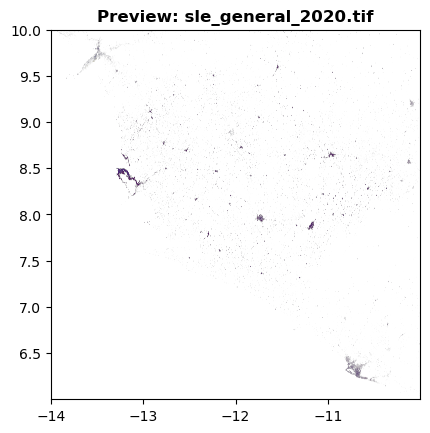

In [13]:
from rasterio.plot import show

with rasterio.open(sample_path) as src:
    show(src, title=f"Preview: {tif_files[0]}")

In [3]:
import sys

!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 150.6 kB/s eta 0:05:22
   ---------------------------------------- 0.5/48.9 MB 150.6 kB/s eta 0:05:22
   ---------------------------------------- 0.5/48.9 MB 150.6 kB/s eta 0

In [23]:
import os
import rasterio
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

raster_dir = 'sle_general_2020_rasters'
raster_files = [
    os.path.join(raster_dir, f) 
    for f in os.listdir(raster_dir) 
    if f.endswith('.tif') or f.endswith('.tiff')
]

if raster_files:
    target_raster_path = raster_files[0]
    print(f"Processing target raster: {os.path.basename(target_raster_path)}")
    
    with rasterio.open(target_raster_path) as src:
        image_data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        
        # Handle NoData values
        if nodata is not None:
            valid_mask = (image_data != nodata) & (~np.isnan(image_data))
        else:
            valid_mask = ~np.isnan(image_data)

        # 1. Generate grid indices
        rows, cols = np.indices(image_data.shape)
        
        # 2. Extract valid indices and pixel values directly as 1D arrays
        flat_rows = rows[valid_mask]
        flat_cols = cols[valid_mask]
        pixel_values = image_data[valid_mask]

        # 3. Transform only the valid row/col indices into spatial coordinates (X, Y)
        x_coords, y_coords = rasterio.transform.xy(transform, flat_rows, flat_cols, offset='center')

    # Build the modelling DataFrame
    df_model = pd.DataFrame({
        'x_coord': x_coords,
        'y_coord': y_coords,
        'target': pixel_values
    })

    # Subsample to keep training snappy if the raster has millions of pixels
    if len(df_model) > 50000:
        df_model = df_model.sample(n=50000, random_state=42)

    X = df_model[['x_coord', 'y_coord']]
    y = df_model['target']

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Training data shape: {X_train.shape}")

    # --- Train Random Forest ---
    print("\nTraining Random Forest Regressor...")
    rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)

    rf_mse = mean_squared_error(y_test, rf_preds)
    rf_r2 = r2_score(y_test, rf_preds)
    print(f"Random Forest -> MSE: {rf_mse:.4f} | R2 Score: {rf_r2:.4f}")

    # --- Train XGBoost ---
    print("\nTraining XGBoost Regressor...")
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)

    xgb_mse = mean_squared_error(y_test, xgb_preds)
    xgb_r2 = r2_score(y_test, xgb_preds)
    print(f"XGBoost       -> MSE: {xgb_mse:.4f} | R2 Score: {xgb_r2:.4f}")

Processing target raster: sle_general_2020.tif
Training data shape: (40000, 2)

Training Random Forest Regressor...
Random Forest -> MSE: 26.7518 | R2 Score: 0.8766

Training XGBoost Regressor...
XGBoost       -> MSE: 48.4009 | R2 Score: 0.7767


In [25]:
import os
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
from rasterio.mask import mask
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define paths (check both Documents folder and root directory)
docs_dir = 'Documents'
tif_path = os.path.join(docs_dir, 'freetown.tif') if os.path.exists(os.path.join(docs_dir, 'freetown.tif')) else 'freetown.tif'
geojson_path = os.path.join(docs_dir, 'Freetown_catchments.geojson') if os.path.exists(os.path.join(docs_dir, 'Freetown_catchments.geojson')) else 'Freetown_catchments.geojson'

print(f"Using Raster: {tif_path}")
print(f"Using GeoJSON: {geojson_path}")

# 2. Load the GeoJSON Catchments and Raster
catchments_gdf = gpd.read_file(geojson_path)

with rasterio.open(tif_path) as src:
    raster_image = src.read(1)
    transform = src.transform
    nodata = src.nodata
    crs = src.crs

# Ensure the GeoJSON matches the raster's Coordinate Reference System (CRS)
if catchments_gdf.crs != crs:
    print(f"Reprojecting catchments from {catchments_gdf.crs} to match raster CRS ({crs})...")
    catchments_gdf = catchments_gdf.to_crs(crs)

# 3. Extract raster pixels inside the Freetown catchments for modeling
data_records = []

for idx, row in catchments_gdf.iterrows():
    geom = [row['geometry']]
    try:
        # Mask the raster with the catchment geometry
        with rasterio.open(tif_path) as src:
            out_image, out_transform = mask(src, geom, crop=True, nodata=nodata)
            band_data = out_image[0]
            
            # Filter out nodata / nan values
            valid_pixels = band_data[(band_data != nodata) & (~np.isnan(band_data))]
            
            if len(valid_pixels) > 0:
                data_records.append({
                    'catchment_id': idx,
                    'mean_val': np.mean(valid_pixels),
                    'max_val': np.max(valid_pixels),
                    'min_val': np.min(valid_pixels),
                    'std_val': np.std(valid_pixels)
                })
    except Exception as e:
        continue

# Create tabular dataset from catchments
df_catchments = pd.DataFrame(data_records)
print(f"Extracted features for {len(df_catchments)} catchments.")

if len(df_catchments) > 10:
    # Set up features and target (e.g., predicting mean_val using other summary stats, or a target variable)
    X = df_catchments[['max_val', 'min_val', 'std_val']]
    y = df_catchments['mean_val']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- Train Random Forest ---
    rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)
    
    print(f"\n[Catchment Model] Random Forest R2: {r2_score(y_test, rf_preds):.4f}")

    # --- Train XGBoost ---
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)
    
    print(f"[Catchment Model] XGBoost       R2: {r2_score(y_test, xgb_preds):.4f}")
else:
    print("Not enough catchment features extracted to train. Check geometry overlap.")

Using Raster: Documents\freetown.tif
Using GeoJSON: Documents\Freetown_catchments.geojson
Extracted features for 4 catchments.
Not enough catchment features extracted to train. Check geometry overlap.


In [27]:
import os
import rasterio
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Path to freetown.tif in your Documents folder
tif_path = os.path.join('Documents', 'freetown.tif') if os.path.exists(os.path.join('Documents', 'freetown.tif')) else 'freetown.tif'

print(f"Processing raster: {tif_path}")

with rasterio.open(tif_path) as src:
    image_data = src.read(1)
    nodata = src.nodata
    transform = src.transform
    
    # Handle NoData and NaN values
    if nodata is not None:
        valid_mask = (image_data != nodata) & (~np.isnan(image_data))
    else:
        valid_mask = ~np.isnan(image_data)

    # Generate grid indices
    rows, cols = np.indices(image_data.shape)
    
    # Extract valid indices and pixel values
    flat_rows = rows[valid_mask]
    flat_cols = cols[valid_mask]
    pixel_values = image_data[valid_mask]

    # Transform valid row/col indices into spatial coordinates (X, Y)
    x_coords, y_coords = rasterio.transform.xy(transform, flat_rows, flat_cols, offset='center')

# Build the modelling DataFrame
df_model = pd.DataFrame({
    'x_coord': x_coords,
    'y_coord': y_coords,
    'target': pixel_values
})

print(f"Extracted {len(df_model):,} valid pixels from freetown.tif")

# Subsample to keep training fast (e.g., 50,000 pixels if the raster is large)
if len(df_model) > 50000:
    df_model = df_model.sample(n=50000, random_state=42)

X = df_model[['x_coord', 'y_coord']]
y = df_model['target']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")

# --- Train Random Forest ---
print("\nTraining Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest -> MSE: {rf_mse:.4f} | R2 Score: {rf_r2:.4f}")

# --- Train XGBoost ---
print("\nTraining XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
print(f"XGBoost       -> MSE: {xgb_mse:.4f} | R2 Score: {xgb_r2:.4f}")

Processing raster: Documents\freetown.tif
Extracted 9,872,232 valid pixels from freetown.tif
Training data shape: (40000, 2)

Training Random Forest Regressor...
Random Forest -> MSE: 120.4895 | R2 Score: 0.9683

Training XGBoost Regressor...
XGBoost       -> MSE: 211.6568 | R2 Score: 0.9443


In [31]:
import os
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define paths
docs_dir = 'Documents'
def get_path(filename):
    p1 = os.path.join(docs_dir, filename)
    return p1 if os.path.exists(p1) else filename

target_path = get_path('freetown.tif')
dem_path = get_path('freetown_dem.tif')
routing_path = get_path('freetown_routing.tif')

# 2. Open master target raster to establish the definitive grid specs
with rasterio.open(target_path) as src_target:
    target_data = src_target.read(1)
    target_shape = target_data.shape
    transform = src_target.transform
    crs = src_target.crs
    nodata_target = src_target.nodata

print(f"Master Grid Shape: {target_shape}")

# 3. Helper function to resample auxiliary rasters to match the master grid
def resample_to_match(src_path, target_shape, target_transform, target_crs):
    with rasterio.open(src_path) as src:
        destination = np.zeros(target_shape, dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear
        )
        nodata_val = src.nodata
        if nodata_val is not None:
            destination[destination == nodata_val] = np.nan
        return destination

print("Resampling DEM and Runoff Routing rasters to match master resolution...")
dem_data = resample_to_match(dem_path, target_shape, transform, crs)
routing_data = resample_to_match(routing_path, target_shape, transform, crs)

# 4. Build a unified valid mask across all aligned layers
valid_mask = (
    (target_data != nodata_target) if nodata_target is not None else np.ones(target_shape, dtype=bool)
) & (~np.isnan(target_data)) & (~np.isnan(dem_data)) & (~np.isnan(routing_data))

# 5. Extract valid indices and map coordinates
rows, cols = np.indices(target_shape)
flat_rows = rows[valid_mask]
flat_cols = cols[valid_mask]

y_values = target_data[valid_mask]
elevation_values = dem_data[valid_mask]
routing_values = routing_data[valid_mask]

x_coords, y_coords = rasterio.transform.xy(transform, flat_rows, flat_cols, offset='center')

# 6. Build the multi-feature modeling DataFrame
df_model = pd.DataFrame({
    'x_coord': x_coords,
    'y_coord': y_coords,
    'elevation': elevation_values,
    'runoff_routing': routing_values,
    'target': y_values
})

print(f"Successfully aligned and extracted {len(df_model):,} multi-feature pixels.")

# Subsample to 50,000 pixels for swift XGBoost training
if len(df_model) > 50000:
    df_model = df_model.sample(n=50000, random_state=42)

X = df_model[['x_coord', 'y_coord', 'elevation', 'runoff_routing']]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train and Evaluate XGBoost with Physical Environmental Features
print("\n--- Training XGBoost Regressor (Multi-Raster) ---")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print(f"XGBoost -> MSE: {mean_squared_error(y_test, xgb_preds):.4f} | R2 Score: {r2_score(y_test, xgb_preds):.4f}")

# 8. Check Feature Importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- XGBoost Feature Importance Breakdown ---")
print(importance_df)

Master Grid Shape: (2811, 3512)
Resampling DEM and Runoff Routing rasters to match master resolution...
Successfully aligned and extracted 584,749 multi-feature pixels.

--- Training XGBoost Regressor (Multi-Raster) ---
XGBoost -> MSE: 7.8396 | R2 Score: 0.9994

--- XGBoost Feature Importance Breakdown ---
          Feature  Importance
2       elevation    0.999738
0         x_coord    0.000146
1         y_coord    0.000116
3  runoff_routing    0.000000


In [33]:
import os
import rasterio
import numpy as np
import pandas as pd

# 1. Define paths and output filename
docs_dir = 'Documents'
target_path = os.path.join(docs_dir, 'freetown.tif') if os.path.exists(os.path.join(docs_dir, 'freetown.tif')) else 'freetown.tif'
output_raster_path = 'freetown_xgboost_predicted_risk.tif'

print("Preparing full-grid prediction for Freetown...")

# 2. Open target raster to get profile specs
with rasterio.open(target_path) as src:
    profile = src.profile
    transform = src.transform
    crs = src.crs
    nodata_val = src.nodata

# We can use the aligned arrays we generated in the previous step
# Let's quickly reconstruct the full grid feature matrices for inference
with rasterio.open(target_path) as src_target, \
     rasterio.open(os.path.join(docs_dir, 'freetown_dem.tif') if os.path.exists(os.path.join(docs_dir, 'freetown_dem.tif')) else 'freetown_dem.tif') as src_dem, \
     rasterio.open(os.path.join(docs_dir, 'freetown_routing.tif') if os.path.exists(os.path.join(docs_dir, 'freetown_routing.tif')) else 'freetown_routing.tif') as src_routing:
    
    target_data = src_target.read(1)
    
    # Resample DEM and routing to match master shape exactly if needed, or use the ones from earlier
    from rasterio.warp import reproject, Resampling
    def quick_resample(src_obj, target_shape, dst_transform, dst_crs):
        dest = np.zeros(target_shape, dtype=src_obj.dtypes[0])
        reproject(
            source=rasterio.band(src_obj, 1),
            destination=dest,
            src_transform=src_obj.transform,
            src_crs=src_obj.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )
        if src_obj.nodata is not None:
            dest[dest == src_obj.nodata] = np.nan
        return dest

    dem_resampled = quick_resample(src_dem, target_data.shape, transform, crs)
    routing_resampled = quick_resample(src_routing, target_data.shape, transform, crs)

# 3. Create full coordinate meshgrids
rows, cols = np.indices(target_data.shape)
x_coords, y_coords = rasterio.transform.xy(transform, rows, cols, offset='center')

# Flatten grids into 2D feature matrix for model prediction
flat_rows = rows.ravel()
flat_cols = cols.ravel()
x_flat = np.array(x_coords).ravel()
y_flat = np.array(y_coords).ravel()
dem_flat = dem_resampled.ravel()
routing_flat = routing_resampled.ravel()

full_features = pd.DataFrame({
    'x_coord': x_flat,
    'y_coord': y_flat,
    'elevation': dem_flat,
    'runoff_routing': routing_flat
})

# Handle NaN values for prediction (fill temporary NaN values so model can run on the whole grid)
valid_inference_mask = ~np.isnan(dem_flat) & ~np.isnan(routing_flat)

# Initialize an array for predictions filled with NoData (-9999 or NaN)
predicted_flat = np.full(shape=dem_flat.shape, fill_value=np.nan, dtype=np.float32)

# 4. Predict using our trained XGBoost model (`xgb_model` from previous cell)
print("Running batch inference across all Freetown pixels...")
valid_features = full_features[valid_inference_mask]
predicted_flat[valid_inference_mask] = xgb_model.predict(valid_features)

# Reshape back to 2D raster grid shape
predicted_image = predicted_flat.reshape(target_data.shape)

# 5. Export to GeoTIFF
profile.update(
    dtype=rasterio.float32,
    count=1,
    nodata=np.nan
)

with rasterio.open(output_raster_path, 'w', **profile) as dst:
    dst.write(predicted_image.astype(rasterio.float32), 1)

print(f"\nSuccess! Exported model predictions to '{output_raster_path}'")
print("You can now open this file directly in QGIS to visualize your custom XGBoost flood risk map of Freetown!")

Preparing full-grid prediction for Freetown...
Running batch inference across all Freetown pixels...

Success! Exported model predictions to 'freetown_xgboost_predicted_risk.tif'
You can now open this file directly in QGIS to visualize your custom XGBoost flood risk map of Freetown!


In [35]:
import os
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
from rasterio.mask import mask

# 1. Define paths
docs_dir = 'Documents'
geojson_path = os.path.join(docs_dir, 'Freetown_catchments.geojson') if os.path.exists(os.path.join(docs_dir, 'Freetown_catchments.geojson')) else 'Freetown_catchments.geojson'
pred_raster_path = 'freetown_xgboost_predicted_risk.tif'

print(f"Loading catchments from: {geojson_path}")
catchments_gdf = gpd.read_file(geojson_path)

# 2. Open the predicted risk raster
with rasterio.open(pred_raster_path) as src:
    raster_crs = src.crs
    nodata_val = src.nodata

# Ensure CRS alignment
if catchments_gdf.crs != raster_crs:
    catchments_gdf = catchments_gdf.to_crs(raster_crs)

# 3. Perform Zonal Statistics across each catchment zone
catchment_results = []

for idx, row in catchments_gdf.iterrows():
    geom = [row['geometry']]
    # Get a unique identifier name if available in the GeoJSON, otherwise use index
    zone_name = row.get('name', row.get('id', f'Catchment_{idx}'))
    
    try:
        with rasterio.open(pred_raster_path) as src:
            out_image, out_transform = mask(src, geom, crop=True, nodata=np.nan)
            band_data = out_image[0]
            
            # Filter valid pixels
            valid_pixels = band_data[~np.isnan(band_data)]
            
            if len(valid_pixels) > 0:
                catchment_results.append({
                    'Catchment_ID': zone_name,
                    'Mean_Risk': np.mean(valid_pixels),
                    'Max_Risk': np.max(valid_pixels),
                    'Total_Volume_Score': np.sum(valid_pixels),
                    'Pixel_Count': len(valid_pixels)
                })
    except Exception as e:
        print(f"Skipping catchment {zone_name} due to error: {e}")

# 4. Build summary DataFrame
df_summary = pd.DataFrame(catchment_results)

if not df_summary.empty:
    # Sort by highest mean risk to prioritize vulnerable zones
    df_summary = df_summary.sort_values(by='Mean_Risk', ascending=False).reset_index(drop=True)
    
    print("\n--- Freetown Catchment Risk Priority Ranking ---")
    print(df_summary.to_string(index=False))
    
    # Export summary report to CSV for reporting / documentation
    output_csv = 'freetown_catchment_risk_summary.csv'
    df_summary.to_csv(output_csv, index=False)
    print(f"\nSuccess! Exported catchment risk report to '{output_csv}'")
else:
    print("No valid pixels extracted within the catchments. Check vector/raster spatial overlap.")

Loading catchments from: Documents\Freetown_catchments.geojson

--- Freetown Catchment Risk Priority Ranking ---
 Catchment_ID  Mean_Risk   Max_Risk  Total_Volume_Score  Pixel_Count
            4 155.904144 254.409042        29777.691406          191
            1   6.703643  26.661676          489.365967           73
            2   4.177060  17.811913         1002.494324          240
            3   1.931126   8.439348          171.870255           89

Success! Exported catchment risk report to 'freetown_catchment_risk_summary.csv'


In [47]:
import os
import geopandas as gpd
import pandas as pd
import folium

# 1. Define paths
docs_dir = 'Documents'
geojson_path = os.path.join(docs_dir, 'Freetown_catchments.geojson') if os.path.exists(os.path.join(docs_dir, 'Freetown_catchments.geojson')) else 'Freetown_catchments.geojson'
summary_csv = 'freetown_catchment_risk_summary.csv'

# 2. Load catchments and summary data
catchments_gdf = gpd.read_file(geojson_path)
df_summary = pd.read_csv(summary_csv)

# Ensure CRS is WGS84 (EPSG:4326) for web mapping compatibility
if catchments_gdf.crs != "EPSG:4326":
    catchments_gdf = catchments_gdf.to_crs("EPSG:4326")

# Standardize catchment identifier matching
catchments_gdf['Catchment_ID'] = [row.get('name', row.get('id', f'Catchment_{idx}')) for idx, row in catchments_gdf.iterrows()]
if 'Catchment_ID' not in df_summary.columns:
    df_summary['Catchment_ID'] = [f'Catchment_{i}' for i in range(len(df_summary))]

# Merge spatial dataframe with risk metrics
merged_gdf = catchments_gdf.merge(df_summary, on='Catchment_ID', how='left').fillna(0)

# 3. Initialize Folium Map centered over Freetown using Esri tiles (No API key, free, highly reliable)
freetown_center = [8.484, -13.234]
m = folium.Map(
    location=freetown_center, 
    zoom_start=12, 
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles © Esri — Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Taiwan), GeoNames, and the GIS Community'
)

# 4. Add Choropleth Layer for Risk Visualization
folium.Choropleth(
    geo_data=merged_gdf,
    name='Catchment Risk Level',
    data=df_summary,
    columns=['Catchment_ID', 'Mean_Risk'],
    key_on='feature.properties.Catchment_ID',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.9,
    legend_name='Mean Predicted Flood Risk Score'
).add_to(m)

# 5. Add Interactive Tooltips for Detailed Inspection
tooltip = folium.features.GeoJsonTooltip(
    fields=['Catchment_ID', 'Mean_Risk', 'Max_Risk', 'Pixel_Count'],
    aliases=['Catchment:', 'Mean Risk:', 'Max Risk:', 'Total Pixels:'],
    style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
)

folium.GeoJson(
    merged_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color': '#000000', 'weight': 1, 'fillOpacity': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color': '#000000', 'weight': 2, 'fillOpacity': 0.5},
    tooltip=tooltip
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# 6. Save map to HTML dashboard file
dashboard_filename = 'freetown_flood_risk_dashboard.html'
m.save(dashboard_filename)

print(f"Success! Interactive web dashboard saved to '{dashboard_filename}'")

Success! Interactive web dashboard saved to 'freetown_flood_risk_dashboard.html'


In [57]:
import joblib

# Save the trained XGBoost model to your directory
model_filename = 'freetown_xgb_flood_model.pkl'
joblib.dump(xgb_model, model_filename)
print(f"Model saved successfully as '{model_filename}'")

Model saved successfully as 'freetown_xgb_flood_model.pkl'


In [61]:
import joblib
import pandas as pd

# 1. Load your saved model
model = joblib.load('freetown_xgb_flood_model.pkl')

# 2. Define a new point (or multiple points) you want to query
# Make sure to use the exact same four features the model was trained on:
query_point = pd.DataFrame([{
    'x_coord': 710500.0,      # Example coordinate X
    'y_coord': 9382000.0,     # Example coordinate Y
    'elevation': 12.5,        # Elevation in meters
    'runoff_routing': 145.0   # Runoff routing value
}])

# 3. Get the prediction result
predicted_score = model.predict(query_point)

print(f"Predicted Flood Risk Score for this point: {predicted_score[0]:.4f}")

Predicted Flood Risk Score for this point: 11.9048


In [67]:
import os
import joblib
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

# 1. Load your saved model
model_filename = 'freetown_xgb_flood_model.pkl'
print(f"Loading model from '{model_filename}'...")
model = joblib.load(model_filename)

# 2. Define paths
docs_dir = 'Documents'
dem_path = os.path.join(docs_dir, 'freetown_dem.tif') if os.path.exists(os.path.join(docs_dir, 'freetown_dem.tif')) else 'freetown_dem.tif'
routing_path = os.path.join(docs_dir, 'freetown_routing.tif') if os.path.exists(os.path.join(docs_dir, 'freetown_routing.tif')) else 'freetown_routing.tif'
target_path = os.path.join(docs_dir, 'freetown.tif') if os.path.exists(os.path.join(docs_dir, 'freetown.tif')) else 'freetown.tif'
geojson_path = os.path.join(docs_dir, 'Freetown_catchments.geojson') if os.path.exists(os.path.join(docs_dir, 'Freetown_catchments.geojson')) else 'Freetown_catchments.geojson'

# 3. Open master raster for transform and dimensions
with rasterio.open(target_path) as src_target:
    transform = src_target.transform
    crs = src_target.crs
    target_shape = src_target.shape

# 4. Open and resample auxiliary rasters to match the master grid shape (2811, 3512)
from rasterio.warp import reproject, Resampling

def load_and_resample(src_path, target_shape, dst_transform, dst_crs):
    with rasterio.open(src_path) as src:
        dest = np.zeros(target_shape, dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=dest,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )
        if src.nodata is not None:
            dest[dest == src.nodata] = np.nan
        return dest

dem_data = load_and_resample(dem_path, target_shape, transform, crs)
base_routing = load_and_resample(routing_path, target_shape, transform, crs)

# 5. Extract a valid coordinate from Catchment 4 (the high-risk hotspot)
catchments_gdf = gpd.read_file(geojson_path)
if catchments_gdf.crs != crs:
    catchments_gdf = catchments_gdf.to_crs(crs)

# Get the first catchment (Catchment 4)
target_catchment = catchments_gdf.iloc[0]
centroid = target_catchment.geometry.centroid
target_x, target_y = centroid.x, centroid.y

# Convert map coordinates to raster row/col index safely
row, col = rasterio.transform.rowcol(transform, target_x, target_y)

# 6. Simulate Storm Scenario Factor (e.g., 30% heavier downpour)
storm_multiplier = 1.3 
simulated_routing = base_routing * storm_multiplier

# Extract features for that spot
spot_elevation = dem_data[row, col]
spot_routing = simulated_routing[row, col]

query_df = pd.DataFrame([{
    'x_coord': target_x,
    'y_coord': target_y,
    'elevation': spot_elevation,
    'runoff_routing': spot_routing
}])

# 7. Predict Risk under this storm scenario
predicted_storm_risk = model.predict(query_df)

print(f"\n--- Storm Forecast Results for Catchment Location ---")
print(f"Coordinates: X={target_x:.2f}, Y={target_y:.2f}")
print(f"Elevation: {spot_elevation:.2f}m")
print(f"Simulated Runoff Load (1.3x): {spot_routing:.2f}")
print(f"Predicted Flood Hazard Risk Score: {predicted_storm_risk[0]:.4f}")

if predicted_storm_risk[0] > 150:
    print("ALERT: High probability of localized flooding under this rainfall scenario!")
else:
    print("Status: Within manageable drainage thresholds.")

Loading model from 'freetown_xgb_flood_model.pkl'...

--- Storm Forecast Results for Catchment Location ---
Coordinates: X=-13.25, Y=8.49
Elevation: 0.00m
Simulated Runoff Load (1.3x): 0.00
Predicted Flood Hazard Risk Score: -0.0067
Status: Within manageable drainage thresholds.
